In [1]:
import numpy as np
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.visualization import simple_norm

from spectral_cube import SpectralCube as sc
from regions import RectangleSkyRegion

%matplotlib widget

In [2]:
def displayimage(cube, region=None):
    img = cube.moment(order=0).value  # moment 0
    fig, ax = plt.subplots(
        figsize=(5, 5), layout="compressed", subplot_kw={"projection": cube.wcs.celestial}
    )
    norm = simple_norm(np.array(img), vmin=0, vmax=np.max(img), stretch="linear")
    im = ax.imshow(img, norm=norm, cmap="viridis", origin="lower")
    lon = ax.coords[0]
    lat = ax.coords[1]
    lon.set_major_formatter("dd")
    lat.set_major_formatter("dd")
    lon.set_axislabel("RA")
    lat.set_axislabel("Dec")
    if region != None:
        region.plot(color="white", ls="--")
    plt.colorbar(im)
    plt.show()

In [3]:
# Combine CRAFTS data cubes

file1 = "./CRAFTS/South/00_DEC_-13.0_-3.0__12_RA_120.0_130.0__-600kms_600kms.I.fits"
file2 = "./CRAFTS/South/00_DEC_-13.0_-3.0__13_RA_130.0_140.0__-600kms_600kms.I.fits"
file3 = "./CRAFTS/South/01_DEC_-3.0_7.0__12_RA_120.0_130.0__-600kms_600kms.I.fits"
file4 = "./CRAFTS/South/01_DEC_-3.0_7.0__13_RA_130.0_140.0__-600kms_600kms.I.fits"

xlo = 120
xhi = 140
ylo = -13
yhi = 1.99

output_file = "CRAFTS_RA120_140_DEC-13_2.fits"

In [4]:
with fits.open(file1) as hdul:
    hdr1 = hdul[0].header
    data1 = hdul[0].data
    hdul.close()

with fits.open(file2) as hdul:
    hdr2 = hdul[0].header
    data2 = hdul[0].data
    hdul.close()

with fits.open(file3) as hdul:
    hdr3 = hdul[0].header
    data3 = hdul[0].data
    hdul.close()

with fits.open(file4) as hdul:
    hdr4 = hdul[0].header
    data4 = hdul[0].data
    hdul.close()

In [5]:
# Combine the images
def combine_matrices(matrix1, matrix2, matrix3, matrix4):
    """
    Combine four matrices into one matrix with the specified order:
        4  3
        2  1

    Parameters:
    - matrix1, matrix2, matrix3, matrix4: numpy arrays of shape (v, y, x)

    Returns:
    - combined_matrix: numpy array of shape (v, 2*y, 2*x)
    """
    # Stack matrices along the vertical axis (rows)
    bottom_row = np.concatenate(
        (matrix4, matrix3), axis=2
    )  # Combine 4 and 2 horizontally
    top_row = np.concatenate((matrix2, matrix1), axis=2)  # Combine 3 and 1 horizontally

    # Stack the two rows along the horizontal axis (columns)
    combined_matrix = np.concatenate((top_row, bottom_row), axis=1)

    return combined_matrix


combined_data = combine_matrices(data1, data2, data3, data4)
# print("Shape of combined data:", combined_data.shape)  # Should be (v, 2*y, 2*x)

In [6]:
# Update the header for the new combined image
combined_header = hdr2

combined_header["BUNIT"] = "K"
combined_header["RESTFRQ"] = 1420405751.77
combined_header["CTYPE1"] = "RA---CAR"
combined_header["CTYPE2"] = "DEC--CAR"
combined_header["CTYPE3"] = "VRAD"
combined_header['CTYPE3'] = (combined_header['CTYPE3'], 'Radio velocity (linear)')
combined_header["SPECSYS"] = "LSRK"
combined_header["VELOSYS"] = 0.0

combined_wcs = WCS(combined_header)

In [7]:
combined_cube = sc(data=combined_data, wcs=combined_wcs)
combined_cube

SpectralCube with shape=(5962, 800, 800):
 n_x:    800  type_x: RA---CAR  unit_x: deg    range:   120.012500 deg:  139.987500 deg
 n_y:    800  type_y: DEC--CAR  unit_y: deg    range:   -12.987500 deg:    6.987500 deg
 n_s:   5962  type_s: VRAD      unit_s: m / s  range:  -599897.172 m / s:  599954.336 m / s

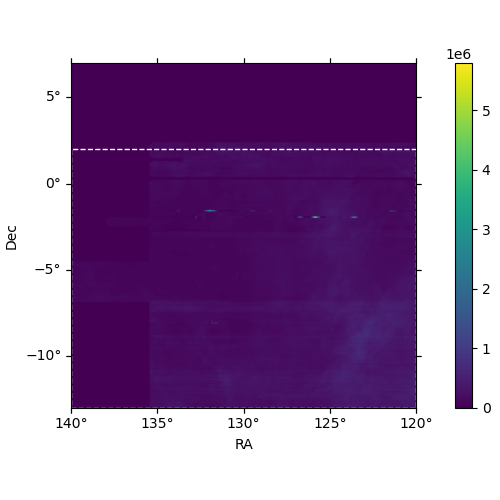

SpectralCube with shape=(5962, 600, 800) and unit=K:
 n_x:    800  type_x: RA---CAR  unit_x: deg    range:   120.012500 deg:  139.987500 deg
 n_y:    600  type_y: DEC--CAR  unit_y: deg    range:   -12.987500 deg:    1.987500 deg
 n_s:   5962  type_s: VRAD      unit_s: m / s  range:  -599897.172 m / s:  599954.336 m / s

In [8]:
# Select a region of the cube

center_sky = SkyCoord((xlo+xhi)/2, (ylo+yhi)/2, unit="deg", frame="fk5")
sky_region = RectangleSkyRegion(center=center_sky, width=(xhi-xlo) * u.deg, height=(yhi-ylo) * u.deg)
pixel_region = sky_region.to_pixel(combined_wcs.celestial)

displayimage(combined_cube, pixel_region)

# Create a subcube using the defined region

region_cube = combined_cube.subcube(
    xlo=xlo * u.deg, xhi=xhi * u.deg, ylo=ylo * u.deg, yhi=yhi * u.deg
)
region_cube.allow_huge_operations = True
region_cube = region_cube * u.K  # Convert to Kelvin
region_cube

In [9]:
# Save the combined image to a new FITS file

region_header = region_cube.header
del region_header["SLICE"]
region_header

BUNIT   = 'K       '                                                            
NAXIS   =                    3                                                  
NAXIS1  =                  800                                                  
NAXIS2  =                  600                                                  
NAXIS3  =                 5962                                                  
WCSAXES =                    3 / Number of coordinate axes                      
CRPIX1  =               5600.5 / Pixel coordinate of reference point            
CRPIX2  =                520.5 / Pixel coordinate of reference point            
CRPIX3  =                  1.0 / Pixel coordinate of reference point            
CDELT1  =               -0.025 / [deg] Coordinate increment at reference point  
CDELT2  =                0.025 / [deg] Coordinate increment at reference point  
CDELT3  =       -201.283594733 / [m/s] Coordinate increment at reference point  
CUNIT1  = 'deg'             

In [10]:
# Save the modified cube with the updated header
hdu = fits.PrimaryHDU(data=region_cube.unmasked_data[:].value, header=region_header)
hdu.writeto(output_file, overwrite=True)  # Replace with your desired output file path